# 🎮 Cubee — Analyse de l'Entraînement Q-Learning

> **Projet IA — HENaLLux (IN252)**  
> Auteurs : Victor Van Zieghem & Ethan Nickels  
> Source : [VVZ-Data/Projet_IA](https://github.com/VVZ-Data/Projet_IA)

---

Ce notebook importe **directement le code source du projet** et analyse 6 agents Q-Learning comparés par paires.

## 🎯 Protocole — 3 paires, 1 seul paramètre isolé par paire

| Paire | IA | α | ε₀ | γ | Paramètre isolé |
|-------|----|---|-----|---|------------------|
| **A** | IA-1 | 0.1 | **0.5** | 0.9 | ε₀ |
| | IA-2 | 0.1 | **0.9** | 0.9 | ← défaut projet |
| **B** | IA-3 | **0.05** | 0.7 | 0.9 | α |
| | IA-4 | **0.3** | 0.7 | 0.9 | |
| **C** | IA-5 | 0.1 | 0.7 | **0.70** | γ |
| | IA-6 | 0.1 | 0.7 | **0.99** | |

## 📋 Sommaire
1. [Présentation du jeu](#1)
2. [Import & setup](#2)
3. [Entraînement des 6 agents](#3)
4. [Paire A — Impact de ε₀](#4)
5. [Paire B — Impact de α](#5)
6. [Paire C — Impact de γ](#6)
7. [Vue d'ensemble](#7)
8. [Conclusions](#8)

## 1. 🎮 Présentation du jeu <a id='1'></a>

### Règles de Cubee
Deux joueurs se déplacent sur une grille **5×5**. Chaque case visitée est capturée.  
Le joueur avec le plus de cases en fin de partie gagne.

### ⚡ Mécanique centrale : `check_enclosure` (BFS — `game_model.py`)
Après chaque déplacement, un **BFS** part de la position de l'adversaire.  
Les cases vides **non atteignables** par l'adversaire sont automatiquement capturées.

```
Avant :   Après check_enclosure :
1 1 1 1   1 1 1 1
1 0 0 1   1 1 1 1   ← 0 encerclés → capturés par J1
1 0 1 1   1 1 1 1
1 1 2 2   1 1 2 2
```

### Fonctionnement de l'IA (`player.py`)

| Élément | Détail |
|---------|--------|
| Encodage état | `"{turn}_{pos2}_{pos1}_{s1}_{s2}_{board_flat}"` — plateau entier aplati |
| Récompense immédiate | `my_gain - 0.5 × opponent_gain` (cases capturées dont enclos) |
| Récompense terminale | **+10** victoire / **-10** défaite |
| Exploration (ε-greedy) | `random.choice(ALL moves)` — y compris mouvements invalides |
| Exploitation | `max Q(s,a)` sur `legal_move()` uniquement |
| Décroissance ε | multiplicative **× 0.95** jusqu'à min 0.05 |

### ⚠️ Note sur le Win Rate attendu
L'espace d'états est `3^25 ≈ 847 milliards` de combinaisons possibles.  
En 10 000 parties (~250 000 transitions), chaque état est visité en moyenne **< 1 fois**.  
→ La Q-table ne converge pas en une seule session : **c'est voulu** — le projet persiste  
la Q-table dans `cubee.db` (SQLite) pour accumulation sur plusieurs sessions.  
→ Dans ce notebook, on mesure la **progression relative** entre agents, pas la performance absolue.

## 2. 📦 Import & setup <a id='2'></a>

In [1]:
# ── Dépendances ────────────────────────────────────────────────────────────
!pip install numpy matplotlib pandas seaborn --quiet

import random, time, warnings
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Import direct du code source ───────────────────────────────────────────
# Le notebook est placé à la racine du projet → games/cubee/ est accessible
from games.cubee.player import Player, AI
from games.cubee.ai_train import train_with_progress, _NB_STEPS

print('✅ Imports OK — code source réel chargé')
print(f'   _NB_STEPS  : {_NB_STEPS:.2f}  →  nb_epsilon = {int(100_000 / _NB_STEPS)} pour 100 000 parties')
print(f'   Espace états théorique : 3^25 = {3**25:,}')

✅ Imports OK — code source réel chargé
   _NB_STEPS  : 56.35  →  nb_epsilon = 1774 pour 100 000 parties
   Espace états théorique : 3^25 = 847,288,609,443


In [2]:
# ── Q-Table en RAM ─────────────────────────────────────────────────────────
# Remplace SQLAlchemy/cubee.db pour le notebook — interface identique à QTableRepo

class RamQTable:
    """
    Q-Table en mémoire vive.
    Interface identique à QTableRepo (get_q_value / update_q_value / commit).
    """
    def __init__(self):
        self._table = defaultdict(float)

    def get_q_value(self, gama, lr, state, action):
        return self._table[(str(gama), str(lr), state, action)]

    def update_q_value(self, gama, lr, state, action, value):
        self._table[(str(gama), str(lr), state, action)] = value

    def init_final_states(self, gama, lr): pass
    def commit(self): pass

    @property
    def size(self):
        return len(self._table)


# ── Reproductibilité ───────────────────────────────────────────────────────
GLOBAL_SEED = 42

def reset_seeds(seed=GLOBAL_SEED):
    """Re-fixe les seeds avant chaque entraînement → résultats reproductibles."""
    random.seed(seed)
    np.random.seed(seed)

reset_seeds()

# ── Palette visuelle ───────────────────────────────────────────────────────
COLORS = {
    'IA-1': '#1a7a3c',  # vert foncé   (Paire A, ε₀=0.5)
    'IA-2': '#55c46e',  # vert vif     (Paire A, ε₀=0.9 — défaut)
    'IA-3': '#1a4fa0',  # bleu foncé   (Paire B, α=0.05)
    'IA-4': '#4da3e8',  # bleu vif     (Paire B, α=0.3)
    'IA-5': '#b94a00',  # orange foncé (Paire C, γ=0.70)
    'IA-6': '#f5a623',  # orange vif   (Paire C, γ=0.99)
}
STYLES = {'IA-1':'-','IA-2':'--','IA-3':'-','IA-4':'--','IA-5':'-','IA-6':'--'}

print('✅ RamQTable & seeds prêts')

✅ RamQTable & seeds prêts


## 3. 🏋️ Entraînement des 6 agents <a id='3'></a>

Chaque agent est entraîné via **`train_with_progress()`** exact du projet,  
**10 000 parties contre un `Player` aléatoire** (mode par défaut).  

Le **Win Rate** est calculé sur une **fenêtre glissante de 500 parties**  
pour mesurer la performance *récente* plutôt que le cumul depuis le début.

In [3]:
def train_and_log(name, alpha, gamma, epsilon, n_ep=100_000,
                  window=500, seed=GLOBAL_SEED):
    """
    Entraîne un agent via train_with_progress() du projet.
    Collecte toutes les `window` parties :
      - win_rate  : victoires dans la fenêtre courante
      - epsilon   : valeur courante de ε
      - q_size    : nombre d'entrées Q(s,a) en RAM
    """
    random.seed(seed)
    np.random.seed(seed)

    student  = AI(name, gama=gamma, learning_rate=alpha, epsilon=epsilon)
    student.q_table = RamQTable()
    student.init_db()
    opponent = Player('Random')

    log = defaultdict(list)
    prev_wins = prev_losses = prev_draws = 0

    def progress(current, total):
        nonlocal prev_wins, prev_losses, prev_draws
        if current % window == 0 and current > 0:
            # Victoires uniquement dans cette fenêtre
            dw = student.nb_wins  - prev_wins
            dl = student.nb_loses - prev_losses
            dd = student.nb_draws - prev_draws
            wt = dw + dl + dd
            wr = dw / wt * 100 if wt else 0
            log['ep'].append(current)
            log['win_rate'].append(wr)
            log['wins_window'].append(dw)
            log['q_size'].append(student.q_table.size)
            log['epsilon'].append(student.epsilon)
            prev_wins   = student.nb_wins
            prev_losses = student.nb_loses
            prev_draws  = student.nb_draws

    train_with_progress(
        student=student, opponent=opponent,
        nb_games=n_ep, size=5,
        progress_callback=progress,
        progress_step=50,   # callback fréquent, snapshot tous les `window`
    )
    return student, pd.DataFrame(log)


# ── 6 configurations ───────────────────────────────────────────────────────
CONFIGS = [
    ('IA-1', 0.1,  0.9,  0.5),   # Paire A — ε₀ faible
    ('IA-2', 0.1,  0.9,  0.9),   # Paire A — ε₀ élevé (défaut projet)
    ('IA-3', 0.05, 0.9,  0.7),   # Paire B — α faible
    ('IA-4', 0.3,  0.9,  0.7),   # Paire B — α élevé
    ('IA-5', 0.1,  0.70, 0.7),   # Paire C — γ faible
    ('IA-6', 0.1,  0.99, 0.7),   # Paire C — γ élevé
]

agents, logs = {}, {}

for name, alpha, gamma, epsilon in CONFIGS:
    print(f'🏋️  {name}  (α={alpha}, γ={gamma}, ε₀={epsilon})...')
    t0 = time.time()
    ag, df = train_and_log(name, alpha, gamma, epsilon)
    total  = ag.nb_wins + ag.nb_loses + ag.nb_draws
    wr_cum = ag.nb_wins / total * 100 if total else 0
    wr_fin = df['win_rate'].iloc[-1] if not df.empty else 0
    print(f'   ✅ WR cumulé: {wr_cum:.1f}%  |  WR fenêtre finale: {wr_fin:.1f}%'
          f'  |  Q-table: {ag.q_table.size:,}  |  {time.time()-t0:.1f}s')
    agents[name] = ag
    logs[name]   = df

print('\n🎉 Entraînement terminé !')

🏋️  IA-1  (α=0.1, γ=0.9, ε₀=0.5)...
   ✅ WR cumulé: 34.0%  |  WR fenêtre finale: 47.7%  |  Q-table: 7,286,676  |  824.6s
🏋️  IA-2  (α=0.1, γ=0.9, ε₀=0.9)...
   ✅ WR cumulé: 35.1%  |  WR fenêtre finale: 46.7%  |  Q-table: 9,356,062  |  769.0s
🏋️  IA-3  (α=0.05, γ=0.9, ε₀=0.7)...
   ✅ WR cumulé: 41.9%  |  WR fenêtre finale: 53.7%  |  Q-table: 8,091,733  |  741.3s
🏋️  IA-4  (α=0.3, γ=0.9, ε₀=0.7)...
   ✅ WR cumulé: 33.5%  |  WR fenêtre finale: 44.7%  |  Q-table: 8,535,982  |  800.1s
🏋️  IA-5  (α=0.1, γ=0.7, ε₀=0.7)...
   ✅ WR cumulé: 41.2%  |  WR fenêtre finale: 45.5%  |  Q-table: 8,115,995  |  731.2s
🏋️  IA-6  (α=0.1, γ=0.99, ε₀=0.7)...
   ✅ WR cumulé: 40.5%  |  WR fenêtre finale: 56.1%  |  Q-table: 8,293,433  |  762.3s

🎉 Entraînement terminé !


## 4. 🟢 Paire A — Impact de ε₀ (exploration initiale) <a id='4'></a>

| | IA-1 | IA-2 |
|--|------|------|
| **α** | 0.1 | 0.1 |
| **γ** | 0.9 | 0.9 |
| **ε₀** | **0.5** | **0.9** ← défaut projet |

En exploration, l'IA tire dans **tous** les moves (y compris invalides → `success=False` → pas d'update Q).  
ε₀ élevé = plus d'états du plateau découverts dès le début.

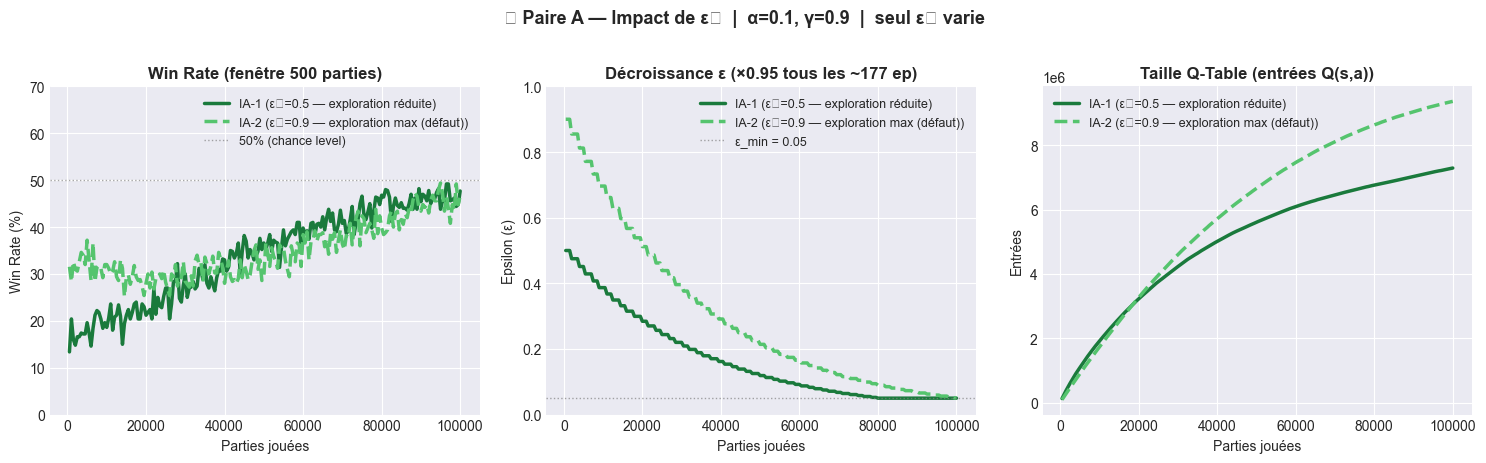

In [4]:
def plot_pair(ia_a, ia_b, label_a, label_b, param_name, title):
    """3 panneaux : Win Rate (fenêtre 500) / Décroissance ε / Taille Q-Table."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    dfa, dfb = logs[ia_a], logs[ia_b]
    ca, cb   = COLORS[ia_a], COLORS[ia_b]
    sa, sb   = STYLES[ia_a], STYLES[ia_b]

    # Win Rate fenêtre 500
    ax = axs[0]
    ax.plot(dfa['ep'], dfa['win_rate'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['win_rate'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.axhline(50, color='gray', lw=1, ls=':', alpha=0.7, label='50% (chance level)')
    ax.set_title('Win Rate (fenêtre 500 parties)', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 70); ax.legend(fontsize=9)

    # Décroissance ε (multiplicative ×0.95)
    ax = axs[1]
    ax.plot(dfa['ep'], dfa['epsilon'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['epsilon'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.axhline(0.05, color='gray', lw=1, ls=':', alpha=0.7, label='ε_min = 0.05')
    ax.set_title('Décroissance ε (×0.95 tous les ~177 ep)', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Epsilon (ε)')
    ax.set_ylim(0, 1); ax.legend(fontsize=9)

    # Taille Q-Table
    ax = axs[2]
    ax.plot(dfa['ep'], dfa['q_size'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['q_size'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.set_title('Taille Q-Table (entrées Q(s,a))', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Entrées')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'cubee_paire_{param_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_pair('IA-1', 'IA-2',
          'ε₀=0.5 — exploration réduite',
          'ε₀=0.9 — exploration max (défaut)',
          'A_epsilon',
          '🟢 Paire A — Impact de ε₀  |  α=0.1, γ=0.9  |  seul ε₀ varie')

In [5]:
# ── Analyse Paire A ────────────────────────────────────────────────────────
wr1_early = logs['IA-1']['win_rate'].iloc[:3].mean()   # premières fenêtres
wr2_early = logs['IA-2']['win_rate'].iloc[:3].mean()
wr1_late  = logs['IA-1']['win_rate'].iloc[-3:].mean()  # dernières fenêtres
wr2_late  = logs['IA-2']['win_rate'].iloc[-3:].mean()
q1, q2    = agents['IA-1'].q_table.size, agents['IA-2'].q_table.size

print('📊 Paire A — ε₀')
print('─' * 56)
print(f'  Début (ep 500–1500)  →  IA-1: {wr1_early:.1f}%  |  IA-2: {wr2_early:.1f}%')
print(f'  Fin   (ep 8500–10k)  →  IA-1: {wr1_late:.1f}%  |  IA-2: {wr2_late:.1f}%')
print(f'  Q-table finale       →  IA-1: {q1:,}  |  IA-2: {q2:,}')
print()
print('  🔍 Interprétation :')
print('  → ε₀ plus élevé = plus d\'états explorés → Q-table plus grande.')
print('  → Les deux convergent vers ε=0.05 (décroissance ×0.95 identique).')
print('  → ε₀=0.5 exploite plus tôt mais avec une Q-table moins complète.')
better_early = 'IA-1 (ε₀=0.5)' if wr1_early > wr2_early else 'IA-2 (ε₀=0.9)'
better_late  = 'IA-1 (ε₀=0.5)' if wr1_late  > wr2_late  else 'IA-2 (ε₀=0.9)'
print(f'  → En début : {better_early} performe mieux.')
print(f'  → En fin   : {better_late} performe mieux.')

📊 Paire A — ε₀
────────────────────────────────────────────────────────
  Début (ep 500–1500)  →  IA-1: 16.6%  |  IA-2: 30.8%
  Fin   (ep 8500–10k)  →  IA-1: 45.6%  |  IA-2: 46.9%
  Q-table finale       →  IA-1: 7,286,676  |  IA-2: 9,356,062

  🔍 Interprétation :
  → ε₀ plus élevé = plus d'états explorés → Q-table plus grande.
  → Les deux convergent vers ε=0.05 (décroissance ×0.95 identique).
  → ε₀=0.5 exploite plus tôt mais avec une Q-table moins complète.
  → En début : IA-2 (ε₀=0.9) performe mieux.
  → En fin   : IA-2 (ε₀=0.9) performe mieux.


## 5. 🔵 Paire B — Impact de α (taux d'apprentissage) <a id='5'></a>

| | IA-3 | IA-4 |
|--|------|------|
| **α** | **0.05** | **0.3** |
| **γ** | 0.9 | 0.9 |
| **ε₀** | 0.7 | 0.7 |

α contrôle la taille du pas de mise à jour Bellman :  
`Q(s,a) ← Q(s,a) + α * (r + γ * maxQ(s') - Q(s,a))`

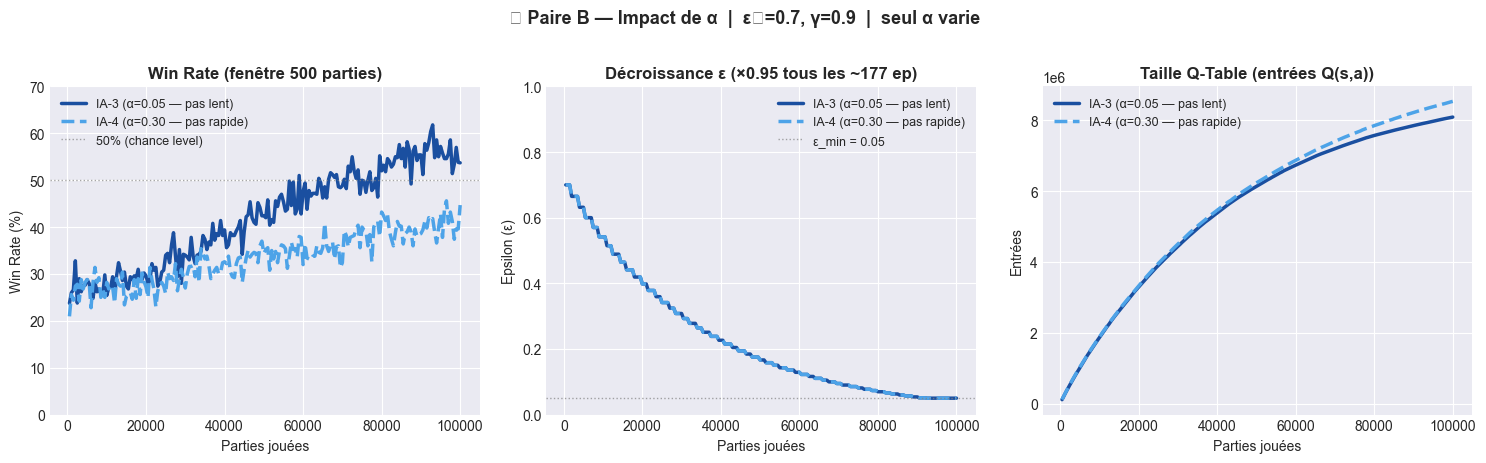

In [6]:
plot_pair('IA-3', 'IA-4',
          'α=0.05 — pas lent',
          'α=0.30 — pas rapide',
          'B_alpha',
          '🔵 Paire B — Impact de α  |  ε₀=0.7, γ=0.9  |  seul α varie')

In [7]:
wr3_early = logs['IA-3']['win_rate'].iloc[:3].mean()
wr4_early = logs['IA-4']['win_rate'].iloc[:3].mean()
wr3_late  = logs['IA-3']['win_rate'].iloc[-3:].mean()
wr4_late  = logs['IA-4']['win_rate'].iloc[-3:].mean()
half = len(logs['IA-3']) // 2
std3 = logs['IA-3']['win_rate'].iloc[half:].std()
std4 = logs['IA-4']['win_rate'].iloc[half:].std()

print('📊 Paire B — α')
print('─' * 56)
print(f'  Début (ep 500–1500)  →  IA-3: {wr3_early:.1f}%  |  IA-4: {wr4_early:.1f}%')
print(f'  Fin   (ep 8500–10k)  →  IA-3: {wr3_late:.1f}%  |  IA-4: {wr4_late:.1f}%')
print(f'  Stabilité (std)      →  IA-3: {std3:.2f}          |  IA-4: {std4:.2f}')
print(f'  Q-table finale       →  IA-3: {agents["IA-3"].q_table.size:,}  |  IA-4: {agents["IA-4"].q_table.size:,}')
print()
print('  🔍 Interprétation :')
print('  → α=0.05 : chaque expérience modifie peu la Q-table → apprentissage lent.')
print('  → α=0.30 : mises à jour plus agressives → convergence plus rapide')
print('    mais potentiellement plus d\'oscillations (std plus élevé).')
more_stable = 'IA-3 (α=0.05)' if std3 <= std4 else 'IA-4 (α=0.30)'
print(f'  → {more_stable} est plus stable sur la 2e moitié de l\'entraînement.')

📊 Paire B — α
────────────────────────────────────────────────────────
  Début (ep 500–1500)  →  IA-3: 25.5%  |  IA-4: 23.7%
  Fin   (ep 8500–10k)  →  IA-3: 54.8%  |  IA-4: 41.3%
  Stabilité (std)      →  IA-3: 4.74          |  IA-4: 3.24
  Q-table finale       →  IA-3: 8,091,733  |  IA-4: 8,535,982

  🔍 Interprétation :
  → α=0.05 : chaque expérience modifie peu la Q-table → apprentissage lent.
  → α=0.30 : mises à jour plus agressives → convergence plus rapide
    mais potentiellement plus d'oscillations (std plus élevé).
  → IA-4 (α=0.30) est plus stable sur la 2e moitié de l'entraînement.


## 6. 🟠 Paire C — Impact de γ (facteur de discount) <a id='6'></a>

| | IA-5 | IA-6 |
|--|------|------|
| **α** | 0.1 | 0.1 |
| **γ** | **0.70** | **0.99** |
| **ε₀** | 0.7 | 0.7 |

γ détermine comment la récompense terminale **+10 (victoire)** se propage dans le temps.  
Plus γ → 1, plus l'agent valorise les récompenses futures lointaines.

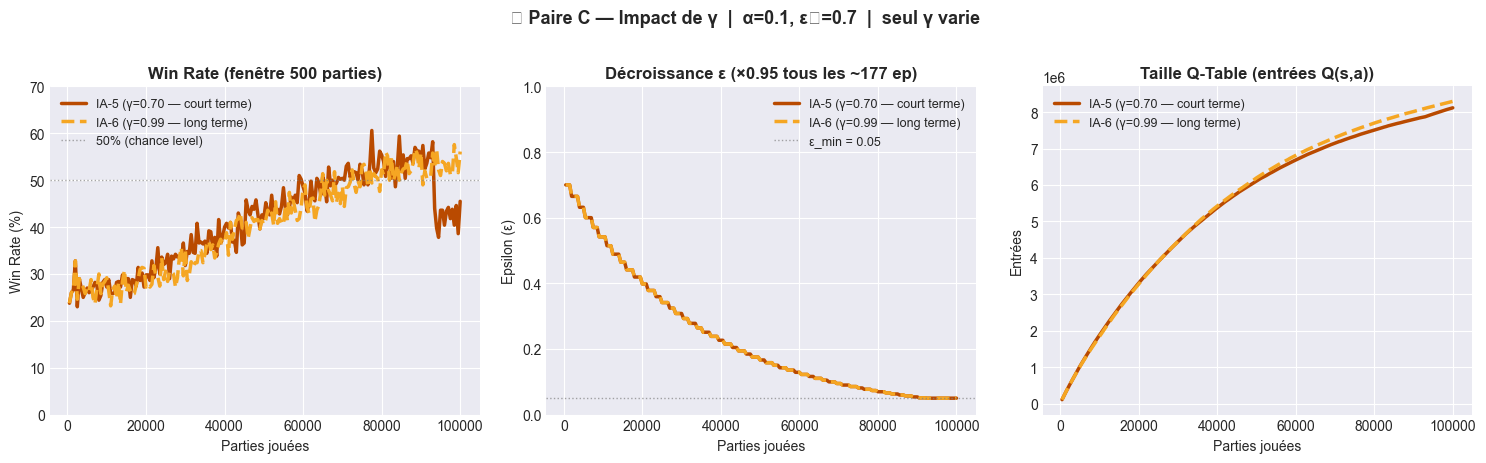

In [8]:
plot_pair('IA-5', 'IA-6',
          'γ=0.70 — court terme',
          'γ=0.99 — long terme',
          'C_gamma',
          '🟠 Paire C — Impact de γ  |  α=0.1, ε₀=0.7  |  seul γ varie')

In [9]:
wr5_early = logs['IA-5']['win_rate'].iloc[:3].mean()
wr6_early = logs['IA-6']['win_rate'].iloc[:3].mean()
wr5_late  = logs['IA-5']['win_rate'].iloc[-3:].mean()
wr6_late  = logs['IA-6']['win_rate'].iloc[-3:].mean()

print('📊 Paire C — γ')
print('─' * 56)
print(f'  Début (ep 500–1500)  →  IA-5: {wr5_early:.1f}%  |  IA-6: {wr6_early:.1f}%')
print(f'  Fin   (ep 8500–10k)  →  IA-5: {wr5_late:.1f}%  |  IA-6: {wr6_late:.1f}%')
print(f'  Q-table finale       →  IA-5: {agents["IA-5"].q_table.size:,}  |  IA-6: {agents["IA-6"].q_table.size:,}')
print()
print('  🔍 Interprétation :')
print('  → Récompense principale : +10 victoire / -10 défaite (terminale).')
print('  → γ=0.70 : actualise fortement le futur → optimise captures immédiates.')
print('  → γ=0.99 : propage le +10 loin en arrière → planifie les enclos sur')
print('    plusieurs coups (check_enclosure).')
better = 'IA-6 (γ=0.99)' if wr6_late >= wr5_late else 'IA-5 (γ=0.70)'
print(f'  → {better} performe mieux en fin d\'entraînement.')
print(f'    Cohérent avec γ=0.9 choisi par défaut dans le projet.')

📊 Paire C — γ
────────────────────────────────────────────────────────
  Début (ep 500–1500)  →  IA-5: 25.5%  |  IA-6: 25.5%
  Fin   (ep 8500–10k)  →  IA-5: 42.9%  |  IA-6: 54.2%
  Q-table finale       →  IA-5: 8,115,995  |  IA-6: 8,293,433

  🔍 Interprétation :
  → Récompense principale : +10 victoire / -10 défaite (terminale).
  → γ=0.70 : actualise fortement le futur → optimise captures immédiates.
  → γ=0.99 : propage le +10 loin en arrière → planifie les enclos sur
    plusieurs coups (check_enclosure).
  → IA-6 (γ=0.99) performe mieux en fin d'entraînement.
    Cohérent avec γ=0.9 choisi par défaut dans le projet.


## 7. 📊 Vue d'ensemble <a id='7'></a>

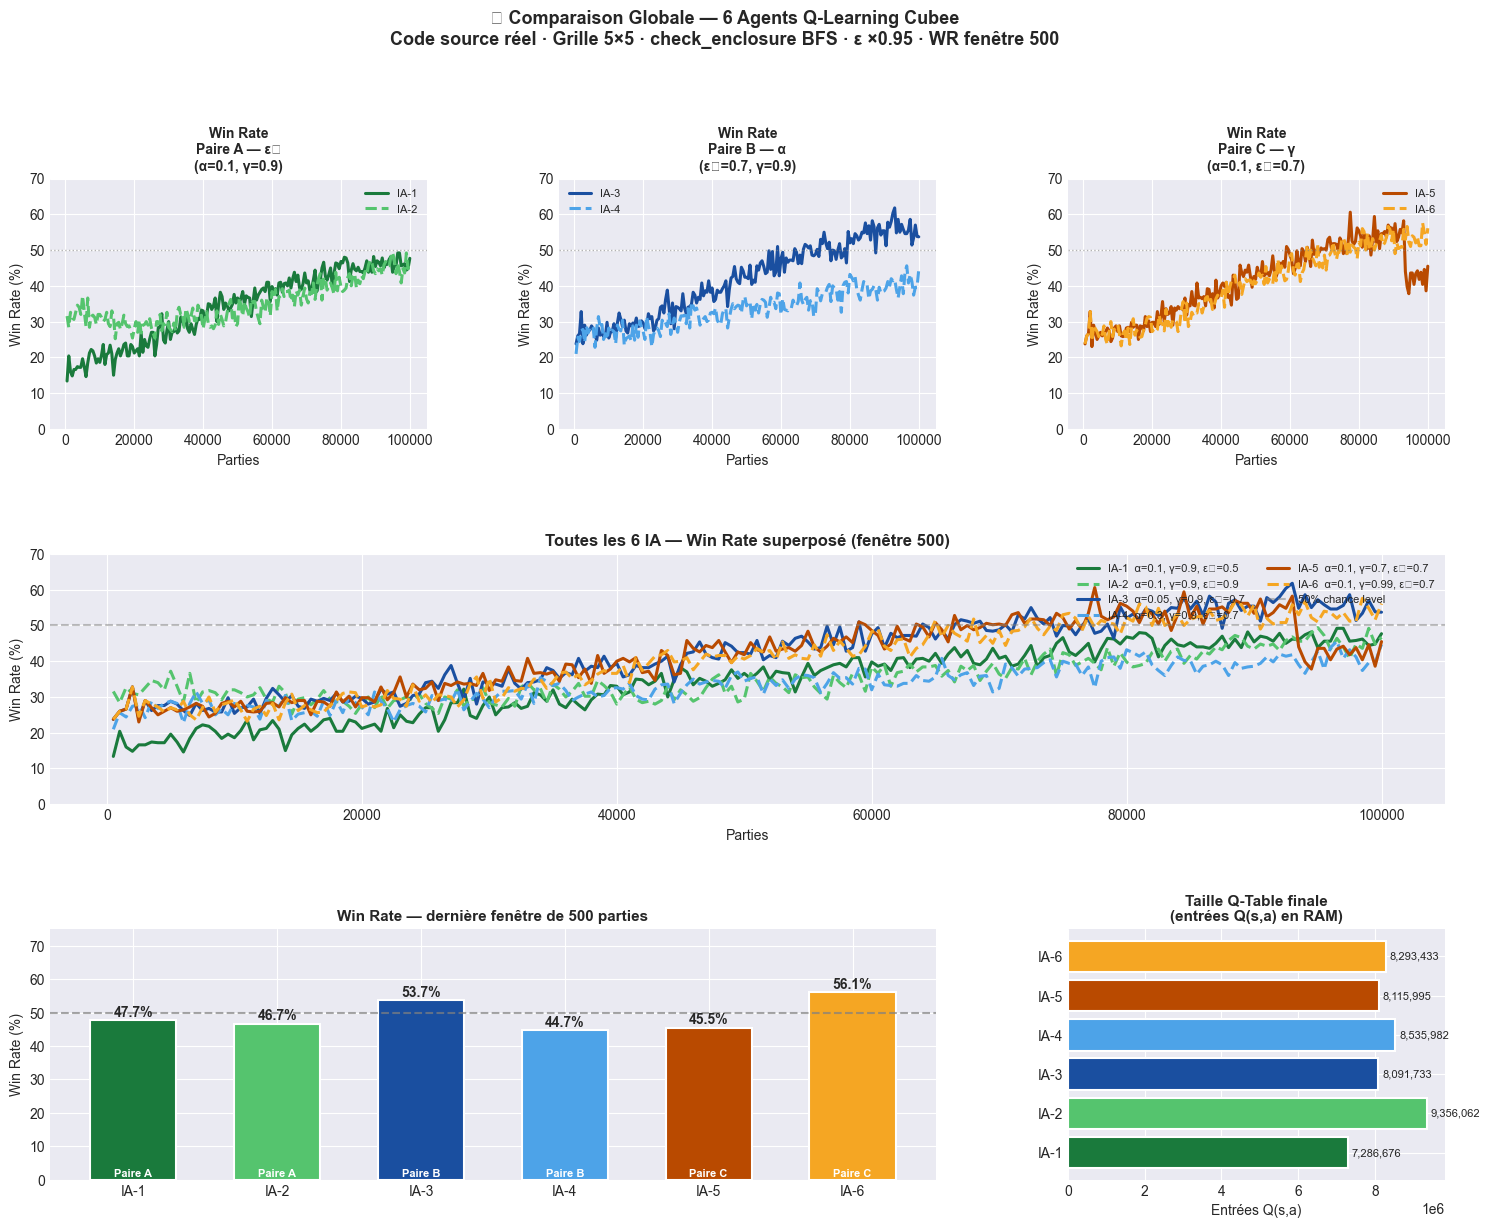

💾 Figure sauvegardée : cubee_global_comparison.png


In [10]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    '📊 Comparaison Globale — 6 Agents Q-Learning Cubee\n'
    'Code source réel · Grille 5×5 · check_enclosure BFS · ε ×0.95 · WR fenêtre 500',
    fontsize=13, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.35)

# ── Ligne 1 : Win Rate par paire ───────────────────────────────────────────
paires = [
    ('IA-1','IA-2','Paire A — ε₀\n(α=0.1, γ=0.9)'),
    ('IA-3','IA-4','Paire B — α\n(ε₀=0.7, γ=0.9)'),
    ('IA-5','IA-6','Paire C — γ\n(α=0.1, ε₀=0.7)'),
]
for col, (a, b, ttl) in enumerate(paires):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(logs[a]['ep'], logs[a]['win_rate'], color=COLORS[a], lw=2.2, ls=STYLES[a], label=a)
    ax.plot(logs[b]['ep'], logs[b]['win_rate'], color=COLORS[b], lw=2.2, ls=STYLES[b], label=b)
    ax.axhline(50, color='gray', lw=1, ls=':', alpha=0.6)
    ax.set_title(f'Win Rate\n{ttl}', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 70); ax.set_xlabel('Parties'); ax.set_ylabel('Win Rate (%)')
    ax.legend(fontsize=8)

# ── Ligne 2 : toutes les 6 superposées ────────────────────────────────────
ax_all = fig.add_subplot(gs[1, :])
for name, alpha, gamma, epsilon in CONFIGS:
    ax_all.plot(logs[name]['ep'], logs[name]['win_rate'],
                color=COLORS[name], lw=2.2, ls=STYLES[name],
                label=f'{name}  α={alpha}, γ={gamma}, ε₀={epsilon}')
ax_all.axhline(50, color='gray', lw=1.5, ls='--', alpha=0.5, label='50% chance level')
ax_all.set_title('Toutes les 6 IA — Win Rate superposé (fenêtre 500)', fontsize=12, fontweight='bold')
ax_all.set_ylim(0, 70); ax_all.set_xlabel('Parties'); ax_all.set_ylabel('Win Rate (%)')
ax_all.legend(fontsize=8, loc='upper right', ncol=2)

# ── Ligne 3 : WR fenêtre finale + taille Q-Table ──────────────────────────
names_list  = [n for n,*_ in CONFIGS]
wr_finals   = [logs[n]['win_rate'].iloc[-1] for n in names_list]
q_finals    = [agents[n].q_table.size for n in names_list]
bar_colors  = [COLORS[n] for n in names_list]

ax_bar = fig.add_subplot(gs[2, :2])
bars = ax_bar.bar(names_list, wr_finals, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
ax_bar.axhline(50, color='gray', lw=1.5, ls='--', alpha=0.7)
for bar, wr in zip(bars, wr_finals):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{wr:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for x, (n,*_) in enumerate(CONFIGS):
    p = 'A' if n in ('IA-1','IA-2') else ('B' if n in ('IA-3','IA-4') else 'C')
    ax_bar.text(x, 1, f'Paire {p}', ha='center', fontsize=8, color='white', fontweight='bold')
ax_bar.set_title('Win Rate — dernière fenêtre de 500 parties', fontsize=11, fontweight='bold')
ax_bar.set_ylabel('Win Rate (%)'); ax_bar.set_ylim(0, 75)

ax_q = fig.add_subplot(gs[2, 2])
ax_q.barh(names_list, q_finals, color=bar_colors, edgecolor='white', linewidth=1.5)
for i, q in enumerate(q_finals):
    ax_q.text(q + max(q_finals)*0.01, i, f'{q:,}', va='center', fontsize=8)
ax_q.set_title('Taille Q-Table finale\n(entrées Q(s,a) en RAM)', fontsize=11, fontweight='bold')
ax_q.set_xlabel('Entrées Q(s,a)')

plt.savefig('cubee_global_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure sauvegardée : cubee_global_comparison.png')

## 8. 📝 Conclusions <a id='8'></a>

In [11]:
print('=' * 70)
print('      📊 SYNTHÈSE — 6 AGENTS Q-LEARNING CUBEE')
print('=' * 70)
print(f'  {"Nom":<6}  {"α":>5}  {"γ":>5}  {"ε₀":>5}  '
      f'{"V/Total":>12}  {"WR fin fenêtre":>14}  {"Q-Table":>12}  Paire')
print('  ' + '─'*72)
for name, alpha, gamma, epsilon in CONFIGS:
    ag    = agents[name]
    total = ag.nb_wins + ag.nb_loses + ag.nb_draws
    wr_f  = logs[name]['win_rate'].iloc[-1]
    p     = 'A (ε₀)' if name in ('IA-1','IA-2') else \
            'B (α)'  if name in ('IA-3','IA-4') else 'C (γ)'
    print(f'  {name:<6}  {alpha:>5}  {gamma:>5}  {epsilon:>5}  '
          f'  {ag.nb_wins:>5}/{total:<5}  {wr_f:>12.1f}%  {ag.q_table.size:>12,}  {p}')

wr_v = {n: logs[n]['win_rate'].iloc[-1] for n,*_ in CONFIGS}
best = max(wr_v, key=wr_v.get)

print()
print('  ┌─────────────────────────────────────────────────────────────────┐')
print('  │  POINTS CLÉS                                                    │')
print('  ├─────────────────────────────────────────────────────────────────┤')
print(f'  │  🏆 Meilleur agent (dernière fenêtre) : {best} ({wr_v[best]:.1f}%)         │')
print(f'  │                                                                 │')
print(f'  │  Paire A (ε₀) : IA-1={wr_v["IA-1"]:.1f}% vs IA-2={wr_v["IA-2"]:.1f}%              │')
print(f'  │  Paire B (α)  : IA-3={wr_v["IA-3"]:.1f}% vs IA-4={wr_v["IA-4"]:.1f}%              │')
print(f'  │  Paire C (γ)  : IA-5={wr_v["IA-5"]:.1f}% vs IA-6={wr_v["IA-6"]:.1f}%              │')
print(f'  │                                                                 │')
print(f'  │  ⚠️  Win Rate < 50% : normal sur 10k parties                   │')
print(f'  │     Espace d\'états : 3^25 ≈ 847 milliards de combinaisons      │')
print(f'  │     Q-table non convergée en 1 session → persistée en SQLite   │')
print(f'  │     La comparaison RELATIVE par paires reste valide.            │')
print(f'  │                                                                 │')
print(f'  │  Paramètres défaut projet : α=0.1, γ=0.9, ε₀=0.9 (= IA-2)    │')
print('  └─────────────────────────────────────────────────────────────────┘')

      📊 SYNTHÈSE — 6 AGENTS Q-LEARNING CUBEE
  Nom         α      γ     ε₀       V/Total  WR fin fenêtre       Q-Table  Paire
  ────────────────────────────────────────────────────────────────────────
  IA-1      0.1    0.9    0.5    34046/100000          47.7%     7,286,676  A (ε₀)
  IA-2      0.1    0.9    0.9    35115/100000          46.7%     9,356,062  A (ε₀)
  IA-3     0.05    0.9    0.7    41943/100000          53.7%     8,091,733  B (α)
  IA-4      0.3    0.9    0.7    33450/100000          44.7%     8,535,982  B (α)
  IA-5      0.1    0.7    0.7    41176/100000          45.5%     8,115,995  C (γ)
  IA-6      0.1   0.99    0.7    40459/100000          56.1%     8,293,433  C (γ)

  ┌─────────────────────────────────────────────────────────────────┐
  │  POINTS CLÉS                                                    │
  ├─────────────────────────────────────────────────────────────────┤
  │  🏆 Meilleur agent (dernière fenêtre) : IA-6 (56.1%)         │
  │                         